# RAG Evaluation with RAGAS — Measuring Retrieval + Generation Quality

Dive deep into **Layer 2 of the eval hierarchy** — evaluating RAG (Retrieval-Augmented Generation) systems with purpose-built metrics. Apply RAGAS to  Financial Analyst RAG agent.

## Business Scenario: Meridian Wealth Partners — Can We Trust the RAG?

**Meridian Wealth Partners** (from Lab 4) uses a RAG-powered Financial Analyst to answer client questions about investment policies. The system retrieves from 5 policy documents and generates answers. But:

1. **Hallucination Risk (₹12 crore exposure):** The analyst sometimes generates plausible-sounding answers that aren't in the source documents. A wrong tax advice could expose the firm to ₹12 crore in client lawsuits.

2. **Irrelevant Retrieval (40% noise):** The retriever pulls 3 chunks per query, but ~40% of retrieved chunks are irrelevant — the generator wastes context on noise.

3. **Missing Context (25% incomplete):** For 25% of queries, the retrieved context doesn't contain all the information needed — the generator has to guess, leading to partial answers.

4. **No Measurement:** The team has no way to quantify these problems. "The RAG seems fine" is not acceptable for a wealth management firm.

**Our Solution:** Apply **RAGAS** (Retrieval Augmented Generation Assessment) — 4 metrics specifically designed to evaluate RAG systems: faithfulness, answer relevancy, context precision, and context recall.

In [1]:
%%capture
!pip install ragas langchain langchain-openai langchain-community faiss-cpu datasets

In [2]:
%%capture
!pip install langchain-classic

In [3]:
# --- API Keys (Google Colab Secrets) ---
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# --- Imports ---
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

import json
import matplotlib.pyplot as plt
import numpy as np

# --- LLM ---
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

print("Imports loaded. RAG evaluation lab ready.")

Imports loaded. RAG evaluation lab ready.


## The 4 RAGAS Metrics

| Metric | What It Measures | Question It Answers | Score Range |
|--------|-----------------|--------------------|-----------|
| **Faithfulness** | Is the answer grounded in the retrieved context? | "Did the generator hallucinate?" | 0.0 - 1.0 |
| **Answer Relevancy** | Is the answer relevant to the question? | "Did the generator address the query?" | 0.0 - 1.0 |
| **Context Precision** | Is the retrieved context actually useful? | "Did the retriever pull relevant chunks?" | 0.0 - 1.0 |
| **Context Recall** | Does the context contain all needed info? | "Did the retriever miss important chunks?" | 0.0 - 1.0 |

```
Question → [Retriever] → Context → [Generator] → Answer
               ↑                          ↑
         context_precision          faithfulness
         context_recall             answer_relevancy
```

In [4]:
# --- Meridian Wealth Partners: Investment Policy Documents ( ) ---
POLICY_DOCS = [
    {
        "title": "Balanced Portfolio Policy",
        "content": """Meridian Balanced Portfolio Policy (BP-2026):\n
Minimum investment: \u20b910,00,000 (Ten Lakhs)\n
Asset allocation: 60% equity, 30% debt, 10% gold\n
Rebalancing: Quarterly, with 5% drift tolerance\n
Lock-in period: 3 years for tax-saving ELSS component\n
Exit load: 1% if redeemed before 1 year\n
Benchmark: Nifty 50 for equity, CRISIL Composite Bond for debt\n
Risk rating: Moderate (suitable for investors with 5+ year horizon)\n
Tax implications: LTCG above \u20b91.25 lakh taxed at 12.5% (equity), 20% with indexation (debt)"""
    },
    {
        "title": "Growth Portfolio Policy",
        "content": """Meridian Growth Portfolio Policy (GP-2026):\n
Minimum investment: \u20b925,00,000 (Twenty-Five Lakhs)\n
Asset allocation: 85% equity, 10% debt, 5% alternative investments\n
Equity breakdown: 50% large-cap, 30% mid-cap, 20% small-cap\n
Rebalancing: Monthly review, quarterly execution\n
Lock-in period: None, but recommended holding 7+ years\n
Exit load: 0.5% if redeemed before 6 months\n
Benchmark: Nifty 500 Total Return Index\n
Risk rating: High (suitable for aggressive investors with 7+ year horizon)\n
Expected returns: 12-15% CAGR over 10-year period (historical, not guaranteed)"""
    },
    {
        "title": "Conservative Income Policy",
        "content": """Meridian Conservative Income Policy (CI-2026):\n
Minimum investment: \u20b95,00,000 (Five Lakhs)\n
Asset allocation: 20% equity, 70% debt, 10% liquid funds\n
Debt instruments: Government bonds (40%), AAA corporate bonds (30%)\n
Monthly income option: Available (\u20b95,000 per \u20b910 lakh invested, approximately)\n
Lock-in period: None\n
Exit load: None\n
Risk rating: Low (suitable for retirees and capital preservation)\n
Tax implications: Interest income taxed as per income slab"""
    },
    {
        "title": "NRI Investment Policy",
        "content": """Meridian NRI Investment Policy (NRI-2026):\n
Eligible: NRIs with NRE/NRO accounts at partner banks\n
Minimum investment: \u20b915,00,000 (Fifteen Lakhs)\n
Repatriation: Fully repatriable from NRE account\n
Tax: DTAA benefits available (India-US, India-UK, India-UAE)\n
KYC: PAN card + passport + overseas address proof required\n
Currency: INR only, forex conversion at bank rates\n
Reporting: Quarterly statement in email + annual tax certificate"""
    },
    {
        "title": "SIP Policy",
        "content": """Meridian SIP (Systematic Investment Plan) Policy:\n
Minimum SIP: \u20b95,000 per month\n
Maximum SIP: \u20b910,00,000 per month\n
Frequency: Monthly (1st, 10th, or 25th of each month)\n
Auto-debit: Available via NACH mandate\n
Step-up SIP: Increase SIP by 10-25% annually\n
Pause: SIP can be paused for up to 3 months without cancellation\n
Tax benefit: ELSS SIPs eligible for Section 80C deduction (up to \u20b91.5 lakh/year)\n
Rupee cost averaging: Key benefit of SIP over lump sum"""
    }
]

print(f"Policy documents loaded: {len(POLICY_DOCS)} documents")
for doc in POLICY_DOCS:
    print(f"  - {doc['title']} ({len(doc['content'])} chars)")

Policy documents loaded: 5 documents
  - Balanced Portfolio Policy (510 chars)
  - Growth Portfolio Policy (572 chars)
  - Conservative Income Policy (463 chars)
  - NRI Investment Policy (435 chars)
  - SIP Policy (460 chars)


In [5]:
# --- Build FAISS Vector Store ( ) ---
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=50,
    separators=["\n\n", "\n", " "]
)

# Create Document objects
all_docs = []
for policy in POLICY_DOCS:
    chunks = text_splitter.split_text(policy["content"])
    for i, chunk in enumerate(chunks):
        all_docs.append(Document(
            page_content=chunk,
            metadata={"source": policy["title"], "chunk_index": i}
        ))

# Build vector store
vectorstore = FAISS.from_documents(all_docs, embeddings)
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

print(f"FAISS index built: {len(all_docs)} chunks from {len(POLICY_DOCS)} documents")

FAISS index built: 7 chunks from 5 documents


In [6]:
# --- Build RAG Chain: Retriever + Generator ---
rag_prompt = ChatPromptTemplate.from_template(
    """You are Meridian Wealth Partners' Financial Analyst AI.
Answer the client's question using ONLY the provided context from our policy documents.
If the context doesn't contain the answer, say "I don't have that information in our policy documents."

Context:
{context}

Client Question: {question}

Provide a clear, accurate answer. Include specific numbers (amounts, percentages) when available.""")

rag_chain = rag_prompt | llm


def ask_rag(question: str) -> dict:
    """Query the RAG system and return question, contexts, and answer."""
    # Retrieve
    retrieved_docs = retriever.invoke(question)
    contexts = [doc.page_content for doc in retrieved_docs]
    context_str = "\n\n---\n\n".join(contexts)

    # Generate
    answer = rag_chain.invoke({"context": context_str, "question": question}).content

    return {"question": question, "contexts": contexts, "answer": answer}


# Quick test
test = ask_rag("What is the minimum investment for the balanced portfolio?")
print(f"Question: {test['question']}")
print(f"Answer: {test['answer'][:200]}")
print(f"Contexts retrieved: {len(test['contexts'])} chunks")

Question: What is the minimum investment for the balanced portfolio?
Answer: The minimum investment for the Meridian Balanced Portfolio is ₹10,00,000 (Ten Lakhs).
Contexts retrieved: 3 chunks


## Build RAG Evaluation Dataset

Each test case has: question, ground truth answer, and optionally the expected source document. We'll let the retriever find contexts dynamically.

In [7]:
# --- 15 QA Evaluation Triples ---
EVAL_DATASET = [
    # Balanced Portfolio (3 questions)
    {"question": "What is the minimum investment for the balanced portfolio?",
     "ground_truth": "The minimum investment for the balanced portfolio is \u20b910,00,000 (Ten Lakhs).",
     "source": "Balanced Portfolio Policy"},
    {"question": "What is the asset allocation in the balanced portfolio?",
     "ground_truth": "The balanced portfolio allocates 60% to equity, 30% to debt, and 10% to gold.",
     "source": "Balanced Portfolio Policy"},
    {"question": "What is the exit load for the balanced portfolio?",
     "ground_truth": "The exit load is 1% if redeemed before 1 year.",
     "source": "Balanced Portfolio Policy"},
    # Growth Portfolio (3 questions)
    {"question": "What are the expected returns for the growth portfolio?",
     "ground_truth": "Expected returns are 12-15% CAGR over a 10-year period (historical, not guaranteed).",
     "source": "Growth Portfolio Policy"},
    {"question": "How is the equity allocation split in the growth portfolio?",
     "ground_truth": "Equity is split as 50% large-cap, 30% mid-cap, and 20% small-cap.",
     "source": "Growth Portfolio Policy"},
    {"question": "What is the minimum investment for the growth portfolio?",
     "ground_truth": "The minimum investment is \u20b925,00,000 (Twenty-Five Lakhs).",
     "source": "Growth Portfolio Policy"},
    # Conservative Income (3 questions)
    {"question": "Is there a monthly income option in the conservative portfolio?",
     "ground_truth": "Yes, approximately \u20b95,000 per \u20b910 lakh invested per month.",
     "source": "Conservative Income Policy"},
    {"question": "What percentage goes to government bonds in the conservative portfolio?",
     "ground_truth": "40% of the debt allocation goes to government bonds.",
     "source": "Conservative Income Policy"},
    {"question": "Is the conservative portfolio suitable for retirees?",
     "ground_truth": "Yes, the risk rating is Low, suitable for retirees and capital preservation.",
     "source": "Conservative Income Policy"},
    # NRI Policy (3 questions)
    {"question": "What KYC documents do NRIs need to invest?",
     "ground_truth": "NRIs need PAN card, passport, and overseas address proof.",
     "source": "NRI Investment Policy"},
    {"question": "Are NRI investments repatriable?",
     "ground_truth": "Yes, fully repatriable from NRE account.",
     "source": "NRI Investment Policy"},
    {"question": "What DTAA benefits are available for NRI investors?",
     "ground_truth": "DTAA benefits are available for India-US, India-UK, and India-UAE.",
     "source": "NRI Investment Policy"},
    # SIP Policy (3 questions)
    {"question": "What is the minimum SIP amount at Meridian?",
     "ground_truth": "The minimum SIP is \u20b95,000 per month.",
     "source": "SIP Policy"},
    {"question": "Can I pause my SIP temporarily?",
     "ground_truth": "Yes, SIP can be paused for up to 3 months without cancellation.",
     "source": "SIP Policy"},
    {"question": "What tax benefit do ELSS SIPs provide?",
     "ground_truth": "ELSS SIPs are eligible for Section 80C deduction up to \u20b91.5 lakh per year.",
     "source": "SIP Policy"},
]

print(f"Evaluation dataset: {len(EVAL_DATASET)} QA pairs")
sources = {}
for q in EVAL_DATASET:
    sources[q['source']] = sources.get(q['source'], 0) + 1
for src, count in sources.items():
    print(f"  {src}: {count} questions")

Evaluation dataset: 15 QA pairs
  Balanced Portfolio Policy: 3 questions
  Growth Portfolio Policy: 3 questions
  Conservative Income Policy: 3 questions
  NRI Investment Policy: 3 questions
  SIP Policy: 3 questions


## Run RAGAS Evaluation

First, run the RAG chain on all 15 questions to collect answers and contexts. Then evaluate with RAGAS metrics.

In [8]:
# --- Run RAG on All 15 Questions ---
print("Running RAG chain on 15 evaluation questions...")
print("=" * 60)

rag_outputs = []
for i, item in enumerate(EVAL_DATASET):
    result = ask_rag(item["question"])
    rag_outputs.append(result)
    print(f"Q{i+1}: {item['question'][:50]}... -> {result['answer'][:80]}...")

print(f"\nAll {len(rag_outputs)} questions answered.")

Running RAG chain on 15 evaluation questions...
Q1: What is the minimum investment for the balanced po... -> The minimum investment for the Meridian Balanced Portfolio is ₹10,00,000 (Ten La...
Q2: What is the asset allocation in the balanced portf... -> The asset allocation in the Meridian Balanced Portfolio is 60% equity, 30% debt,...
Q3: What is the exit load for the balanced portfolio?... -> The exit load for the Meridian Balanced Portfolio is 1% if redeemed before 1 yea...
Q4: What are the expected returns for the growth portf... -> The expected returns for the Meridian Growth Portfolio are 12-15% CAGR over a 10...
Q5: How is the equity allocation split in the growth p... -> In the Meridian Growth Portfolio, the equity allocation is 85% of the total inve...
Q6: What is the minimum investment for the growth port... -> The minimum investment for the Meridian Growth Portfolio (GP-2026) is ₹25,00,000...
Q7: Is there a monthly income option in the conservati... -> Yes, the Meridian Cons

In [9]:
# --- Run RAGAS Evaluation ---
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from datasets import Dataset

# Prepare dataset in RAGAS format
ragas_data = {
    "question": [item["question"] for item in EVAL_DATASET],
    "answer": [output["answer"] for output in rag_outputs],
    "contexts": [output["contexts"] for output in rag_outputs],
    "ground_truth": [item["ground_truth"] for item in EVAL_DATASET],
}

ragas_dataset = Dataset.from_dict(ragas_data)

print("Running RAGAS evaluation (4 metrics)...")
print("This may take 2-3 minutes.")

ragas_results = evaluate(
    dataset=ragas_dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
)

print("\nRAGAS Evaluation Complete!")
print("=" * 60)
print(ragas_results)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_13992/3516080618.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_13992/3516080618.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metri

Running RAGAS evaluation (4 metrics)...
This may take 2-3 minutes.


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[1]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[5]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[9]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[13]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[17]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[21]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[25]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[29]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executo


RAGAS Evaluation Complete!
{'faithfulness': 0.9333, 'answer_relevancy': nan, 'context_precision': 1.0000, 'context_recall': 1.0000}


In [10]:
# --- Per-Question Scores ---
results_df = ragas_results.to_pandas()
print("Per-Question RAGAS Scores")
print("=" * 80)
for i, row in results_df.iterrows():
    q = EVAL_DATASET[i]["question"][:45]
    print(f"Q{i+1}: {q:45s} | faith={row.get('faithfulness', 0):.2f} rel={row.get('answer_relevancy', 0):.2f} prec={row.get('context_precision', 0):.2f} rec={row.get('context_recall', 0):.2f}")

Per-Question RAGAS Scores
Q1: What is the minimum investment for the balanc | faith=1.00 rel=nan prec=1.00 rec=1.00
Q2: What is the asset allocation in the balanced  | faith=1.00 rel=nan prec=1.00 rec=1.00
Q3: What is the exit load for the balanced portfo | faith=1.00 rel=nan prec=1.00 rec=1.00
Q4: What are the expected returns for the growth  | faith=1.00 rel=nan prec=1.00 rec=1.00
Q5: How is the equity allocation split in the gro | faith=1.00 rel=nan prec=1.00 rec=1.00
Q6: What is the minimum investment for the growth | faith=1.00 rel=nan prec=1.00 rec=1.00
Q7: Is there a monthly income option in the conse | faith=1.00 rel=nan prec=1.00 rec=1.00
Q8: What percentage goes to government bonds in t | faith=0.75 rel=nan prec=1.00 rec=1.00
Q9: Is the conservative portfolio suitable for re | faith=1.00 rel=nan prec=1.00 rec=1.00
Q10: What KYC documents do NRIs need to invest?    | faith=1.00 rel=nan prec=1.00 rec=1.00
Q11: Are NRI investments repatriable?              | faith=1.00 rel=nan p

## Interpreting RAGAS Scores

- **Faithfulness < 0.7:** Hallucination risk — the generator is making things up
- **Answer Relevancy < 0.7:** The answer doesn't address the question well
- **Context Precision < 0.5:** The retriever is pulling irrelevant chunks (noise)
- **Context Recall < 0.5:** The retriever is missing important chunks

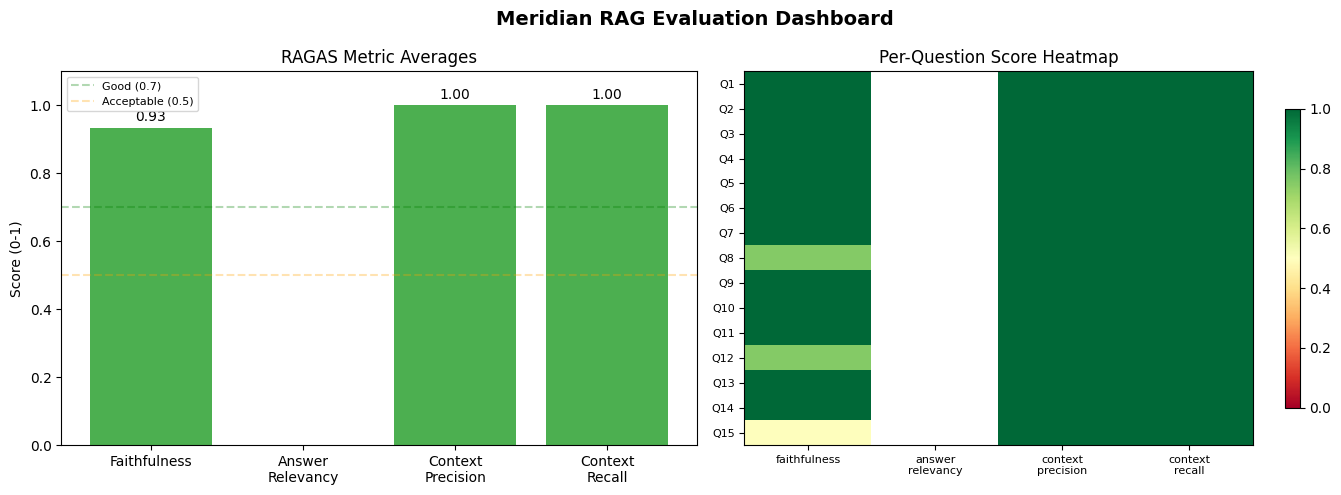


Weakest metric: faithfulness (0.93)


In [11]:
# --- Visualize RAGAS Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overall metric averages
metrics = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
metric_labels = ['Faithfulness', 'Answer\nRelevancy', 'Context\nPrecision', 'Context\nRecall']
avgs = [results_df[m].mean() if m in results_df.columns else 0 for m in metrics]
colors = ['#4CAF50' if v >= 0.7 else '#FF9800' if v >= 0.5 else '#F44336' for v in avgs]

bars = ax1.bar(metric_labels, avgs, color=colors)
ax1.set_title('RAGAS Metric Averages')
ax1.set_ylabel('Score (0-1)')
ax1.set_ylim(0, 1.1)
ax1.axhline(y=0.7, color='green', linestyle='--', alpha=0.3, label='Good (0.7)')
ax1.axhline(y=0.5, color='orange', linestyle='--', alpha=0.3, label='Acceptable (0.5)')
ax1.legend(fontsize=8)
for bar, v in zip(bars, avgs):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

# Right: Per-question heatmap
available_metrics = [m for m in metrics if m in results_df.columns]
if available_metrics:
    heatmap_data = results_df[available_metrics].values
    im = ax2.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax2.set_xticks(range(len(available_metrics)))
    ax2.set_xticklabels([m.replace('_', '\n') for m in available_metrics], fontsize=8)
    ax2.set_yticks(range(len(EVAL_DATASET)))
    ax2.set_yticklabels([f"Q{i+1}" for i in range(len(EVAL_DATASET))], fontsize=8)
    ax2.set_title('Per-Question Score Heatmap')
    plt.colorbar(im, ax=ax2, shrink=0.8)

plt.suptitle('Meridian RAG Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify weakest metric
if avgs:
    weakest_idx = avgs.index(min(avgs))
    print(f"\nWeakest metric: {metrics[weakest_idx]} ({avgs[weakest_idx]:.2f})")

## Improve RAG: Adjust Chunk Size and Re-Evaluate

If context precision is low, the chunks may be too large (mixing relevant and irrelevant text). Let's try smaller chunks and re-evaluate.

In [12]:
# --- Improvement: Smaller Chunk Size (300 instead of 500) ---
print("Rebuilding vector store with smaller chunks (300 vs 500)...")

text_splitter_v2 = RecursiveCharacterTextSplitter(
    chunk_size=300, chunk_overlap=50,  # Smaller chunks for more precise retrieval
    separators=["\n\n", "\n", " "]
)

all_docs_v2 = []
for policy in POLICY_DOCS:
    chunks = text_splitter_v2.split_text(policy["content"])
    for i, chunk in enumerate(chunks):
        all_docs_v2.append(Document(page_content=chunk, metadata={"source": policy["title"]}))

vectorstore_v2 = FAISS.from_documents(all_docs_v2, embeddings)
retriever_v2 = vectorstore_v2.as_retriever(search_type="similarity", search_kwargs={"k": 3})

print(f"V1: {len(all_docs)} chunks (chunk_size=500)")
print(f"V2: {len(all_docs_v2)} chunks (chunk_size=300)")

# Re-run RAG with improved retriever
def ask_rag_v2(question):
    retrieved_docs = retriever_v2.invoke(question)
    contexts = [doc.page_content for doc in retrieved_docs]
    context_str = "\n\n---\n\n".join(contexts)
    answer = rag_chain.invoke({"context": context_str, "question": question}).content
    return {"question": question, "contexts": contexts, "answer": answer}

# Re-run on all 15 questions
print("\nRe-running RAG with improved retriever...")
rag_outputs_v2 = [ask_rag_v2(item["question"]) for item in EVAL_DATASET]

# Re-evaluate with RAGAS
ragas_data_v2 = {
    "question": [item["question"] for item in EVAL_DATASET],
    "answer": [output["answer"] for output in rag_outputs_v2],
    "contexts": [output["contexts"] for output in rag_outputs_v2],
    "ground_truth": [item["ground_truth"] for item in EVAL_DATASET],
}

print("Running RAGAS on improved RAG...")
ragas_results_v2 = evaluate(
    dataset=Dataset.from_dict(ragas_data_v2),
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
)

print("\nIMPROVED RAGAS Results:")
print(ragas_results_v2)

# Compare
print("\nBefore vs After:")
results_df_v2 = ragas_results_v2.to_pandas()
for m in metrics:
    if m in results_df.columns and m in results_df_v2.columns:
        v1 = results_df[m].mean()
        v2 = results_df_v2[m].mean()
        delta = v2 - v1
        print(f"  {m}: {v1:.3f} -> {v2:.3f} ({delta:+.3f})")

Rebuilding vector store with smaller chunks (300 vs 500)...
V1: 7 chunks (chunk_size=500)
V2: 11 chunks (chunk_size=300)

Re-running RAG with improved retriever...
Running RAGAS on improved RAG...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[1]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[5]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[9]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[13]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[17]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[21]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[25]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executor:Exception raised in Job[29]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')
ERROR:ragas.executo


IMPROVED RAGAS Results:
{'faithfulness': 0.9328, 'answer_relevancy': nan, 'context_precision': 0.9722, 'context_recall': 1.0000}

Before vs After:
  faithfulness: 0.933 -> 0.933 (-0.001)
  answer_relevancy: nan -> nan (+nan)
  context_precision: 1.000 -> 0.972 (-0.028)
  context_recall: 1.000 -> 1.000 (+0.000)


## Alternative: DeepEval's FaithfulnessMetric

RAGAS isn't the only RAG evaluation library. **DeepEval** provides similar metrics with a slightly different API. Here's how the same faithfulness eval looks with DeepEval.

In [13]:
# --- DeepEval FaithfulnessMetric (Reference Pattern) ---
# Note: Requires `pip install deepeval` which may have dependency conflicts with RAGAS.
# Showing the pattern here for reference.

DEEPEVAL_REFERENCE = '''
from deepeval.metrics import FaithfulnessMetric
from deepeval.test_case import LLMTestCase

# Define the metric
faithfulness_metric = FaithfulnessMetric(threshold=0.7)

# Create test case
test_case = LLMTestCase(
    input="What is the minimum SIP amount?",
    actual_output="The minimum SIP amount is Rs 5,000 per month.",
    retrieval_context=["Meridian SIP Policy: Minimum SIP: Rs 5,000 per month..."]
)

# Measure
faithfulness_metric.measure(test_case)
print(f"Score: {faithfulness_metric.score}")
print(f"Passed: {faithfulness_metric.is_successful()}")
print(f"Reason: {faithfulness_metric.reason}")
'''

print("DeepEval Pattern (Reference):")
print("  - FaithfulnessMetric with threshold=0.7")
print("  - LLMTestCase with input, actual_output, retrieval_context")
print("  - measure() returns score + reason")
print("\nRAGAS vs DeepEval:")
print("  RAGAS: Batch evaluation with Dataset, 4 specialized metrics")
print("  DeepEval: Per-test-case evaluation, threshold-based pass/fail")
print("  Both: LLM-powered, measure faithfulness and relevancy")

DeepEval Pattern (Reference):
  - FaithfulnessMetric with threshold=0.7
  - LLMTestCase with input, actual_output, retrieval_context
  - measure() returns score + reason

RAGAS vs DeepEval:
  RAGAS: Batch evaluation with Dataset, 4 specialized metrics
  DeepEval: Per-test-case evaluation, threshold-based pass/fail
  Both: LLM-powered, measure faithfulness and relevancy


## How OpenAI Evaluates RAG

OpenAI doesn't provide specialized RAG metrics like RAGAS. Instead, they recommend using **GPT-4 as a judge** with custom rubrics for faithfulness and relevancy.

**OpenAI Cookbook Eval Recipes (further reading):**
- [Evaluate RAG with LlamaIndex](https://developers.openai.com/cookbook/examples/evaluation/evaluate_rag_with_llamaindex)
- [Abstractive Summarization Evaluation](https://developers.openai.com/cookbook/examples/evaluation/how_to_eval_abstractive_summarization)
- [GPT-4o as Judge](https://developers.openai.com/cookbook/examples/evaluation/use_gpt4o_as_judge_for_model_graded_evals)
- [All Eval Recipes](https://developers.openai.com/cookbook/topic/evals)

## Conclusion
In this , we evaluated Meridian Wealth Partners' Financial Analyst RAG with **4 RAGAS metrics**:
- **Faithfulness:** Does the answer stay true to retrieved documents?
- **Answer Relevancy:** Does the answer address the question?
- **Context Precision:** Is the retrieved context relevant?
- **Context Recall:** Does the context contain all needed information?

We also demonstrated the **improvement cycle**: smaller chunk sizes → better context precision → re-evaluate.

